In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [3]:
assets = ['AAPL', 'MSFT', 'AMZN', 'KO', 'JPM']

prices =yf.download(
    assets,
    start ='2020-10-10',
    end ='2026-01-01',
    auto_adjust = True
)

prices.head()

[*********************100%***********************]  5 of 5 completed


Price            Close                                                \
Ticker            AAPL        AMZN        JPM         KO        MSFT   
Date                                                                   
2020-10-12  120.560730  172.146500  88.270317  42.782227  210.551605   
2020-10-13  117.362572  172.181503  86.839920  42.053699  211.940018   
2020-10-14  117.449806  168.185501  86.357384  41.969955  210.038055   
2020-10-15  116.984634  166.932495  87.649887  41.861095  208.896820   
2020-10-16  115.346779  163.635498  87.468971  41.894588  208.896820   

Price             High                                                ...  \
Ticker            AAPL        AMZN        JPM         KO        MSFT  ...   
Date                                                                  ...   
2020-10-12  121.316656  174.811996  88.752855  43.150677  212.891074  ...   
2020-10-13  121.520173  174.619003  88.942417  42.698490  214.174875  ...   
2020-10-14  119.233016  173.244003  87.830853  42.279792  213.233419  ...   
2020-10-15  117.459510  167.794006  87.701586  41.978329  209.562518  ...   
2020-10-16  117.798704  169.983002  88.175547  42.162553  211.397942  ...   

Price             Open                                                \
Ticker            AAPL        AMZN        JPM         KO        MSFT   
Date                                                                   
2020-10-12  116.354669  167.496994  87.115665  42.572879  208.069492   
2020-10-13  121.403874  173.399506  88.752847  42.698490  211.806878   
2020-10-14  117.265668  172.350006  87.055341  41.911338  212.073197   
2020-10-15  115.056052  164.600494  85.392288  41.367036  206.462261   
2020-10-16  117.537032  168.161499  87.382805  41.861095  209.362801   

Price          Volume                                           
Ticker           AAPL       AMZN       JPM        KO      MSFT  
Date                                                            
2020-10-12  240226800  167284000  16058000  11386500  40461400  
2020-10-13  262330500  114894000  21697300  14365300  28950800  
2020-10-14  150712000  116254000  15204100  10582100  23421700  
2020-10-15  112559200  104468000  17171200   9961700  22733100  
2020-10-16  115393800  129488000  13275000  13569800  26057900  

[5 rows x 25 columns]

In [4]:
returns = prices['Close'].pct_change()
returns = returns.dropna()
returns.head()

Ticker,AAPL,AMZN,JPM,KO,MSFT
Date,,,,,
2020-10-13,-0.026527,0.000203,-0.016205,-0.017029,0.006594
2020-10-14,0.000743,-0.023208,-0.005557,-0.001991,-0.008974
2020-10-15,-0.003961,-0.007450,0.014967,-0.002594,-0.005433
2020-10-16,-0.014001,-0.019750,-0.002064,0.000800,0.000000
2020-10-19,-0.025542,-0.020014,-0.016846,-0.008195,-0.024765


In [5]:
mean_daily_returns = returns.mean()
mean_daily_returns

Ticker
AAPL    0.000774
AMZN    0.000465
JPM     0.001098
KO      0.000412
MSFT    0.000760
dtype: float64

In [6]:
annual_returns = mean_daily_returns * 252
annual_returns

Ticker
AAPL    0.194963
AMZN    0.117298
JPM     0.276758
KO      0.103888
MSFT    0.191587
dtype: float64

In [7]:
daily_volatility = returns.std()

daily_volatility

Ticker
AAPL    0.017671
AMZN    0.022004
JPM     0.015844
KO      0.010224
MSFT    0.016184
dtype: float64

In [8]:
annual_volatility = daily_volatility * np.sqrt(252)

annual_volatility

Ticker
AAPL    0.280514
AMZN    0.349308
JPM     0.251522
KO      0.162297
MSFT    0.256918
dtype: float64

In [9]:
covariance = returns.cov()
correlation = returns.corr()

print("Covariance Matrix:")
display(covariance)

print("Correlation Matrix:")
display(correlation)

Covariance Matrix:


Ticker,AAPL,AMZN,JPM,KO,MSFT
Ticker,,,,,
AAPL,0.000312,0.000220,0.000089,0.000048,0.000181
AMZN,0.000220,0.000484,0.000106,0.000022,0.000235
JPM,0.000089,0.000106,0.000251,0.000044,0.000075
KO,0.000048,0.000022,0.000044,0.000105,0.000033
MSFT,0.000181,0.000235,0.000075,0.000033,0.000262


Correlation Matrix:


Ticker,AAPL,AMZN,JPM,KO,MSFT
Ticker,,,,,
AAPL,1.000000,0.566881,0.316521,0.263388,0.633402
AMZN,0.566881,1.000000,0.304410,0.096422,0.660096
JPM,0.316521,0.304410,1.000000,0.272152,0.290869
KO,0.263388,0.096422,0.272152,1.000000,0.198828
MSFT,0.633402,0.660096,0.290869,0.198828,1.000000


In [10]:
weights = np.array([0.20, 0.20, 0.20, 0.20, 0.20])

print("Total weight:", weights.sum())

Total weight: 1.0


In [11]:
portfolio_return = np.dot(weights, annual_returns)

annual_covariance = returns.cov() * 252

portfolio_variance = weights.T @ annual_covariance @ weights
portfolio_volatility = np.sqrt(portfolio_variance)

print(f"Portfolio annual return: {portfolio_return:.2%}")
print(f"Portfolio annual volatility: {portfolio_volatility:.2%}")

Portfolio annual return: 17.69%
Portfolio annual volatility: 18.83%


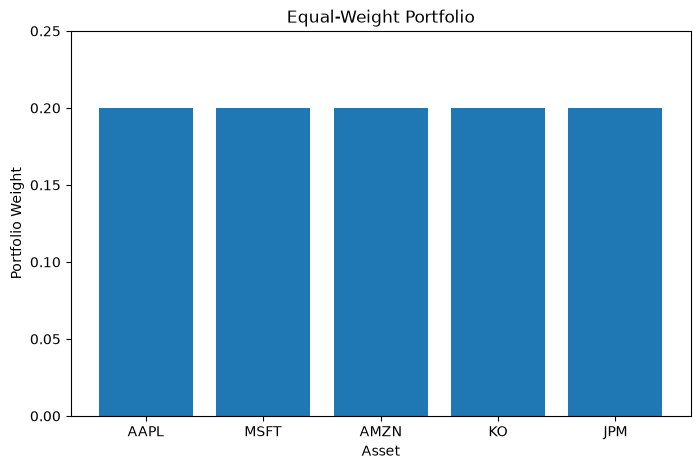

In [12]:
labels = assets

plt.figure(figsize=(8, 5))
plt.bar(labels, weights)

plt.title("Equal-Weight Portfolio")
plt.xlabel("Asset")
plt.ylabel("Portfolio Weight")
plt.ylim(0, 0.25)

plt.show()

In [13]:
from scipy.optimize import minimize

# Expected returns and covariance matrix
mu = annual_returns[assets].to_numpy()
cov = (returns[assets].cov() * 252).to_numpy()

# Portfolio functions
def portfolio_return(weights):
    return weights @ mu

def portfolio_volatility(weights):
    return np.sqrt(weights @ cov @ weights)

# Start with equal weights
initial_weights = np.array([0.20] * 5)

# All weights must add up to 1
constraints = ({
    "type": "eq",
    "fun": lambda weights: np.sum(weights) - 1
})

# No short selling: each weight must be between 0% and 100%
bounds = tuple((0, 1) for _ in assets)

# Minimise portfolio volatility
result = minimize(
    portfolio_volatility,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

optimal_weights = result.x

print("Optimal weights:")
for asset, weight in zip(assets, optimal_weights):
    print(f"{asset}: {weight:.2%}")

print(f"\nTotal weight: {optimal_weights.sum():.2%}")
print(f"Portfolio return: {portfolio_return(optimal_weights):.2%}")
print(f"Portfolio volatility: {portfolio_volatility(optimal_weights):.2%}")

Optimal weights:
AAPL: 1.06%
MSFT: 15.57%
AMZN: 2.66%
KO: 65.91%
JPM: 14.81%

Total weight: 100.00%
Portfolio return: 14.45%
Portfolio volatility: 14.34%


In [14]:
def negative_return(weights):
    return -portfolio_return(weights)

result_max_return = minimize(
    negative_return,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

max_return_weights = result_max_return.x

print("Maximum-return portfolio:")

for asset, weight in zip(assets, max_return_weights):
    print(f"{asset}: {weight:.2%}")

print(f"\nTotal weight: {max_return_weights.sum():.2%}")
print(f"Portfolio return: {portfolio_return(max_return_weights):.2%}")
print(f"Portfolio volatility: {portfolio_volatility(max_return_weights):.2%}")

Maximum-return portfolio:
AAPL: 0.00%
MSFT: 0.00%
AMZN: 0.00%
KO: 0.00%
JPM: 100.00%

Total weight: 100.00%
Portfolio return: 27.68%
Portfolio volatility: 25.15%


In [15]:
annual_returns[assets]

Ticker
AAPL    0.194963
MSFT    0.191587
AMZN    0.117298
KO      0.103888
JPM     0.276758
dtype: float64

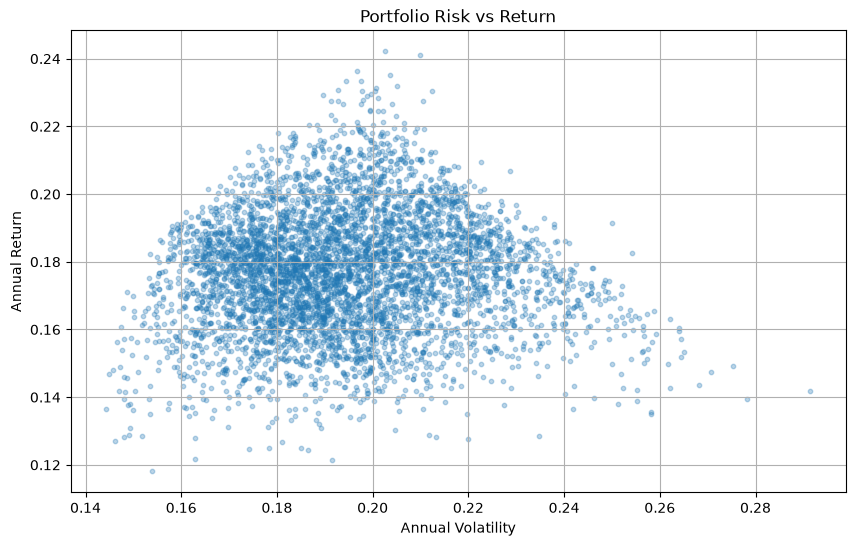

In [16]:
num_portfolios = 5000

portfolio_returns = []
portfolio_volatilities = []
portfolio_weights = []

for _ in range(num_portfolios):
    random_weights = np.random.random(len(assets))
    random_weights /= np.sum(random_weights)

    ret = portfolio_return(random_weights)
    vol = portfolio_volatility(random_weights)

    portfolio_returns.append(ret)
    portfolio_volatilities.append(vol)
    portfolio_weights.append(random_weights)

plt.figure(figsize=(10, 6))

plt.scatter(
    portfolio_volatilities,
    portfolio_returns,
    alpha=0.3,
    s=10
)

plt.xlabel("Annual Volatility")
plt.ylabel("Annual Return")
plt.title("Portfolio Risk vs Return")
plt.grid(True)

plt.show()

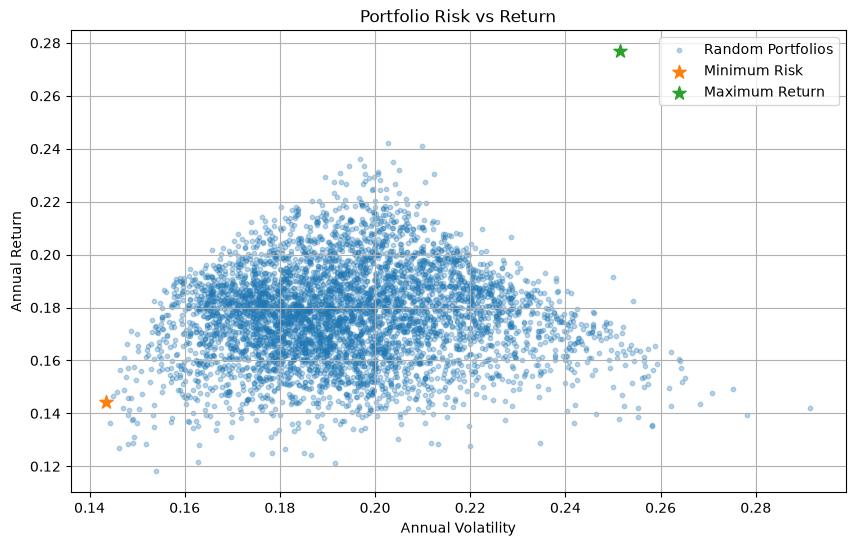

In [17]:
plt.figure(figsize=(10, 6))

plt.scatter(
    portfolio_volatilities,
    portfolio_returns,
    alpha=0.3,
    s=10,
    label="Random Portfolios"
)

# Minimum-risk portfolio
min_risk = portfolio_volatility(optimal_weights)
min_risk_return = portfolio_return(optimal_weights)

plt.scatter(
    min_risk,
    min_risk_return,
    s=100,
    marker="*",
    label="Minimum Risk"
)

# Maximum-return portfolio
max_return = portfolio_return(max_return_weights)
max_return_vol = portfolio_volatility(max_return_weights)

plt.scatter(
    max_return_vol,
    max_return,
    s=100,
    marker="*",
    label="Maximum Return"
)

plt.xlabel("Annual Volatility")
plt.ylabel("Annual Return")
plt.title("Portfolio Risk vs Return")
plt.legend()
plt.grid(True)

plt.show()

In [18]:
target_returns = np.linspace(
    portfolio_return(optimal_weights),
    portfolio_return(max_return_weights),
    50
)

efficient_volatilities = []

for target in target_returns:

    constraints_frontier = (
        {
            "type": "eq",
            "fun": lambda weights: np.sum(weights) - 1
        },
        {
            "type": "eq",
            "fun": lambda weights, target=target:
                portfolio_return(weights) - target
        }
    )

    result_frontier = minimize(
        portfolio_volatility,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints_frontier
    )

    efficient_volatilities.append(
        portfolio_volatility(result_frontier.x)
    )

print("Efficient frontier calculated!")
print(f"Number of portfolios: {len(target_returns)}")

Efficient frontier calculated!
Number of portfolios: 50


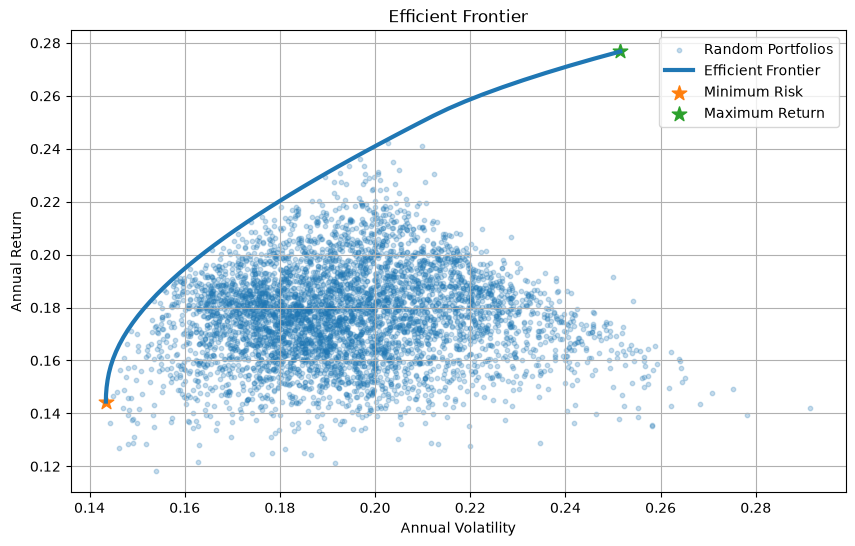

In [19]:
plt.figure(figsize=(10, 6))

# Random portfolios
plt.scatter(
    portfolio_volatilities,
    portfolio_returns,
    alpha=0.25,
    s=10,
    label="Random Portfolios"
)

# Efficient frontier
plt.plot(
    efficient_volatilities,
    target_returns,
    linewidth=3,
    label="Efficient Frontier"
)

# Minimum-risk portfolio
plt.scatter(
    min_risk,
    min_risk_return,
    s=120,
    marker="*",
    label="Minimum Risk"
)

# Maximum-return portfolio
plt.scatter(
    max_return_vol,
    max_return,
    s=120,
    marker="*",
    label="Maximum Return"
)

plt.xlabel("Annual Volatility")
plt.ylabel("Annual Return")
plt.title("Efficient Frontier")
plt.legend()
plt.grid(True)

plt.show()

In [20]:
risk_free_rate = 0.04

def negative_sharpe_ratio(weights):
    ret = portfolio_return(weights)
    vol = portfolio_volatility(weights)

    sharpe = (ret - risk_free_rate) / vol

    return -sharpe

result_sharpe = minimize(
    negative_sharpe_ratio,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

sharpe_weights = result_sharpe.x

sharpe_return = portfolio_return(sharpe_weights)
sharpe_volatility = portfolio_volatility(sharpe_weights)
sharpe_ratio = (sharpe_return - risk_free_rate) / sharpe_volatility

print("Maximum Sharpe Ratio Portfolio:")

for asset, weight in zip(assets, sharpe_weights):
    print(f"{asset}: {weight:.2%}")

print(f"\nTotal weight: {sharpe_weights.sum():.2%}")
print(f"Portfolio return: {sharpe_return:.2%}")
print(f"Portfolio volatility: {sharpe_volatility:.2%}")
print(f"Sharpe ratio: {sharpe_ratio:.2f}")

Maximum Sharpe Ratio Portfolio:
AAPL: 6.80%
MSFT: 20.55%
AMZN: 0.00%
KO: 11.14%
JPM: 61.51%

Total weight: 100.00%
Portfolio return: 23.44%
Portfolio volatility: 19.34%
Sharpe ratio: 1.01


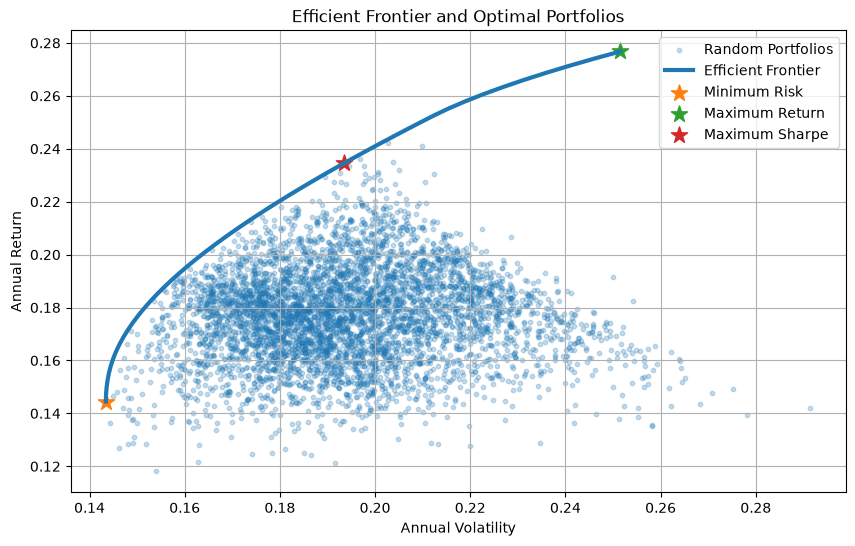

In [21]:
plt.figure(figsize=(10, 6))

# Random portfolios
plt.scatter(
    portfolio_volatilities,
    portfolio_returns,
    alpha=0.25,
    s=10,
    label="Random Portfolios"
)

# Efficient frontier
plt.plot(
    efficient_volatilities,
    target_returns,
    linewidth=3,
    label="Efficient Frontier"
)

# Minimum-risk portfolio
plt.scatter(
    min_risk,
    min_risk_return,
    s=150,
    marker="*",
    label="Minimum Risk"
)

# Maximum-return portfolio
plt.scatter(
    max_return_vol,
    max_return,
    s=150,
    marker="*",
    label="Maximum Return"
)

# Maximum-Sharpe portfolio
plt.scatter(
    sharpe_volatility,
    sharpe_return,
    s=150,
    marker="*",
    label="Maximum Sharpe"
)

plt.xlabel("Annual Volatility")
plt.ylabel("Annual Return")
plt.title("Efficient Frontier and Optimal Portfolios")
plt.legend()
plt.grid(True)

plt.show()

In [22]:
comparison = pd.DataFrame({
    "Portfolio": [
        "Equal Weight",
        "Minimum Risk",
        "Maximum Return",
        "Maximum Sharpe"
    ],
    "Expected Return": [
        portfolio_return(initial_weights),
        min_risk_return,
        max_return,
        sharpe_return
    ],
    "Volatility": [
        portfolio_volatility(initial_weights),
        min_risk,
        max_return_vol,
        sharpe_volatility
    ],
    "Sharpe Ratio": [
        (portfolio_return(initial_weights) - risk_free_rate)
        / portfolio_volatility(initial_weights),

        (min_risk_return - risk_free_rate) / min_risk,

        (max_return - risk_free_rate) / max_return_vol,

        sharpe_ratio
    ]
})

comparison["Expected Return"] = comparison["Expected Return"].map(
    lambda x: f"{x:.2%}"
)

comparison["Volatility"] = comparison["Volatility"].map(
    lambda x: f"{x:.2%}"
)

comparison["Sharpe Ratio"] = comparison["Sharpe Ratio"].map(
    lambda x: f"{x:.2f}"
)

comparison

,Portfolio,Expected Return,Volatility,Sharpe Ratio
0,Equal Weight,17.69%,18.83%,0.73
1,Minimum Risk,14.45%,14.34%,0.73
2,Maximum Return,27.68%,25.15%,0.94
3,Maximum Sharpe,23.44%,19.34%,1.01


In [26]:
comparison.to_csv("../results/portfolio_comparison.csv", index=False)

weights_df = pd.DataFrame({
    "Asset": assets,
    "Minimum Risk": optimal_weights,
    "Maximum Sharpe": sharpe_weights,
    "Maximum Return": max_return_weights
})

weights_df.to_csv("../results/optimal_weights.csv", index=False)

print("Results saved successfully!")

Results saved successfully!


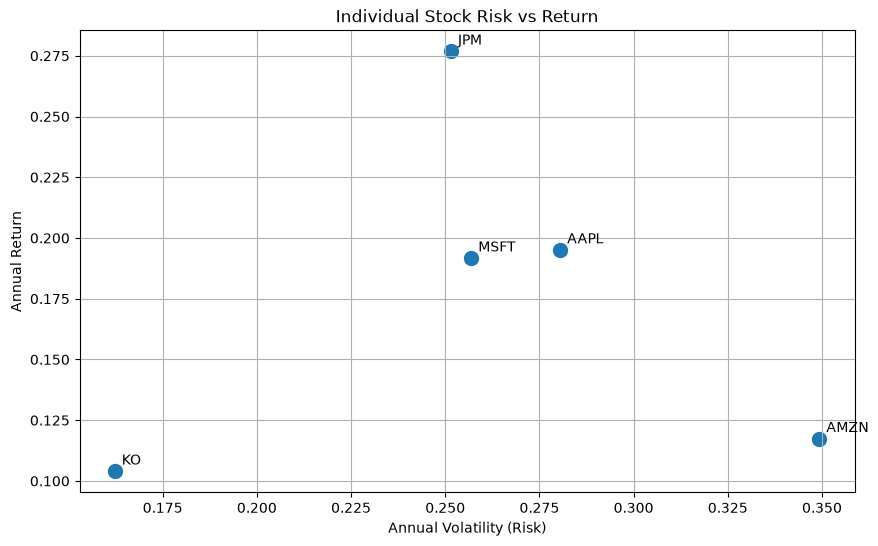

In [30]:
asset_returns = annual_returns[assets]
asset_volatility = returns[assets].std() * np.sqrt(252)

plt.figure(figsize=(10, 6))

plt.scatter(
    asset_volatility,
    asset_returns,
    s=100
)

for asset in assets:
    plt.annotate(
        asset,
        (
            asset_volatility[asset],
            asset_returns[asset]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Annual Volatility (Risk)")
plt.ylabel("Annual Return")
plt.title("Individual Stock Risk vs Return")
plt.grid(True)
plt.savefig("../results/efficient_frontier.png", dpi=300, bbox_inches="tight")
plt.show()

### Individual Stock Risk and Return Analysis

The risk-return analysis compares the annualised historical returns and volatility of five stocks: Apple (AAPL), Microsoft (MSFT), Amazon (AMZN), JPMorgan Chase (JPM), and Coca-Cola (KO).

JPM recorded the highest annualised historical return at approximately 27.68%, although its return was accompanied by volatility. KO had the lowest annualised volatility, at approximately 16%, but also recorded the lowest annualised return at approximately 10.39%.

AMZN showed the highest volatility among the five stocks, at approximately 35%, while its historical annualised return was approximately 11.73%. AAPL and MSFT delivered similar historical returns of approximately 19.50% and 19.16%, respectively.

These findings illustrate the relationship between historical return and risk. However, individual stock performance alone does not determine the best portfolio. Correlations between assets and diversification also affect overall portfolio risk.

*Note: Historical returns and volatility are based on the selected data period and do not guarantee future performance.*


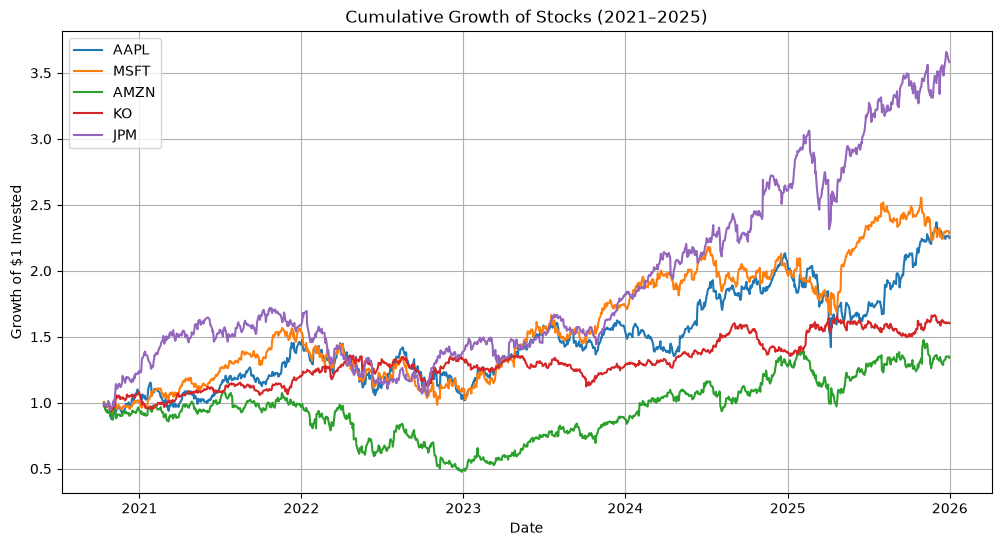

In [29]:
# Calculate cumulative growth from daily returns
cumulative_returns = (1 + returns[assets]).cumprod()

# Plot cumulative growth
plt.figure(figsize=(12, 6))

for asset in assets:
    plt.plot(
        cumulative_returns.index,
        cumulative_returns[asset],
        label=asset
    )

plt.title("Cumulative Growth of Stocks (2021–2025)")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Invested")
plt.legend()
plt.grid(True)
plt.savefig("../results/cumulative_returns.png", dpi=300, bbox_inches="tight")
plt.show()